In [151]:
# This Notebook is used to analyse the spetral band shape of DMX data


In [152]:
# imports
import numpy as np
import pandas
import matplotlib.pyplot as plt
import os


In [153]:
path = '/Users/laurent/data/TestPlan21-perfo/'

file = 'bandShapeFbck/mesure_front_montee_FPAsim.csv'


In [154]:
# Parameters for the spectral analysis. The unit seems to be per sqrt(Hz). I don't know why...
xlabel = r'Frequencies $(Hz)$'
#ylabel = r'Noise $\left(V_{rms} /\sqrt{Hz}\right)$'
ylabel = r'Noise $\left( \frac{V_{rms}} {\sqrt{Hz}} \right)$'
scaling = 'spectrum'
#scaling = 'density'
ymin = 1e-9
ymax = 1e-5

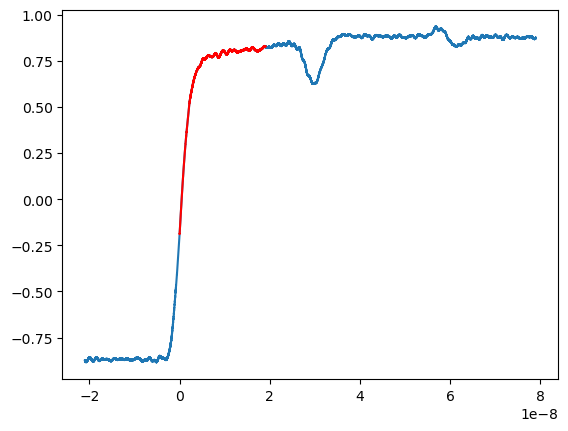

In [155]:
fullFileName = os.path.join(path, file)
df = pandas.read_csv(fullFileName)
iStart = 17
df.columns = ["t", "v"]

t = np.array(df.loc[iStart:, "t"].astype(float))
v = np.array(df.loc[iStart:, "v"].astype(float))

it1 = 10500
#it1 = 9300
it2 = 20000
#it2 = 40000

plt.plot(t,v)
plt.plot(t[it1: it2],v[it1: it2], color='r')


In [156]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Définition de la fonction exponentielle
def exponential_response(t, U0, tau):
    return U0 * (1 - np.exp(-t / tau))

# Fonction de fit pour trouver la constante de temps
def fit_time_constant(t_data, v_data):
    # Ajustement des données pour trouver les paramètres U0 et tau
    popt, pcov = curve_fit(exponential_response, t_data, v_data, p0=[max(v_data), t_data[np.argmax(v_data)]])
    U0, tau = popt
    return U0, tau


Constante de temps :  1.834 ns
Frequence de coupure : 86.790 MHz


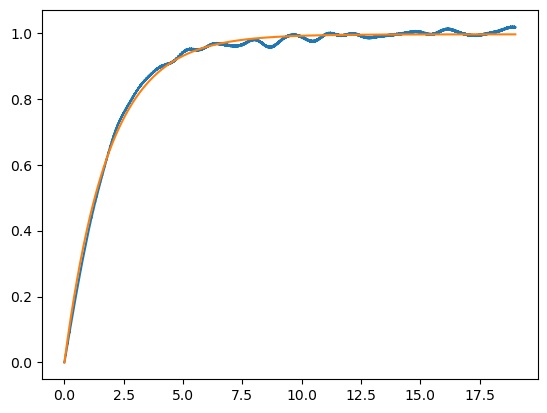

In [157]:
# Calcul du fit
v = v[it1:it2] - v[it1]
t = t[it1:it2] - t[it1]
U0, tau = fit_time_constant(t, v)
print("Constante de temps : {0:6.3f} ns".format(tau*1e9))
print("Frequence de coupure : {0:6.3f} MHz".format(1/(2*np.pi*tau*1e6)))


plt.plot(t*1e9, v)
plt.plot(t*1e9, exponential_response(t, U0, tau))